<a href="https://www.kaggle.com/code/lalit7881/cr7-goal-analytics?scriptVersionId=303708197" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sigmaborov/ronaldo-cr7-all-goals-goat/README.md
/kaggle/input/datasets/sigmaborov/ronaldo-cr7-all-goals-goat/ronaldo_goals_kaggle_ready.csv


## Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/sigmaborov/ronaldo-cr7-all-goals-goat/ronaldo_goals_kaggle_ready.csv')

df.head()

,competition,stage,match_date,home_away,team,opponent,final_score,player_position,goal_minute,score_after_goal,goal_method,assist_player,season,goal_decade,is_home_goal,goal_minute_bucket
0,Liga Portugal,6,07/10/02,Home,Sporting CP,Moreirense FC,3:0,LW,34',2:0,Solo run,Not Applicable,2002/03,2000s,1,31-45
1,Liga Portugal,6,07/10/02,Home,Sporting CP,Moreirense FC,3:0,LW,90'+5,3:0,Header,Rui Jorge,2002/03,2000s,1,76-90
2,Liga Portugal,8,26/10/02,Away,Sporting CP,Boavista FC,1:2,Not Applicable,88',1:2,Right-footed shot,Carlos Martins,2002/03,2000s,0,76-90
3,Taça de Portugal,Fourth Round,24/11/02,Home,Sporting CP,CD Estarreja,4:1,LW,67',3:1,Left-footed shot,César Prates,2002/03,2000s,1,61-75
4,Taça de Portugal,Fifth Round,18/12/02,Home,Sporting CP,FC Oliveira do Hospital,8:1,SS,13',3:0,Left-footed shot,Ricardo Fernandes,2002/03,2000s,1,01-15


## Dataset Shape

In [3]:
df.shape

(816, 16)

## Column Names

In [4]:
df.columns

Index(['competition', 'stage', 'match_date', 'home_away', 'team', 'opponent',
       'final_score', 'player_position', 'goal_minute', 'score_after_goal',
       'goal_method', 'assist_player', 'season', 'goal_decade', 'is_home_goal',
       'goal_minute_bucket'],
      dtype='object')

## Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   competition         816 non-null    object
 1   stage               816 non-null    object
 2   match_date          816 non-null    object
 3   home_away           816 non-null    object
 4   team                816 non-null    object
 5   opponent            816 non-null    object
 6   final_score         816 non-null    object
 7   player_position     816 non-null    object
 8   goal_minute         816 non-null    object
 9   score_after_goal    816 non-null    object
 10  goal_method         816 non-null    object
 11  assist_player       816 non-null    object
 12  season              816 non-null    object
 13  goal_decade         816 non-null    object
 14  is_home_goal        816 non-null    int64 
 15  goal_minute_bucket  816 non-null    object
dtypes: int64(1), object(15)
me

## Summary Statistics

In [6]:
df.describe()

,is_home_goal
count,816.000000
mean,0.567402
std,0.495740
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


## Check Missing Values

In [7]:
df.isnull().sum()

competition           0
stage                 0
match_date            0
home_away             0
team                  0
opponent              0
final_score           0
player_position       0
goal_minute           0
score_after_goal      0
goal_method           0
assist_player         0
season                0
goal_decade           0
is_home_goal          0
goal_minute_bucket    0
dtype: int64

## Check Duplicate Rows

In [8]:
df.duplicated().sum()

np.int64(0)

## Remove duplicates

In [9]:
df = df.drop_duplicates()

## EDA

## Goals by Competition

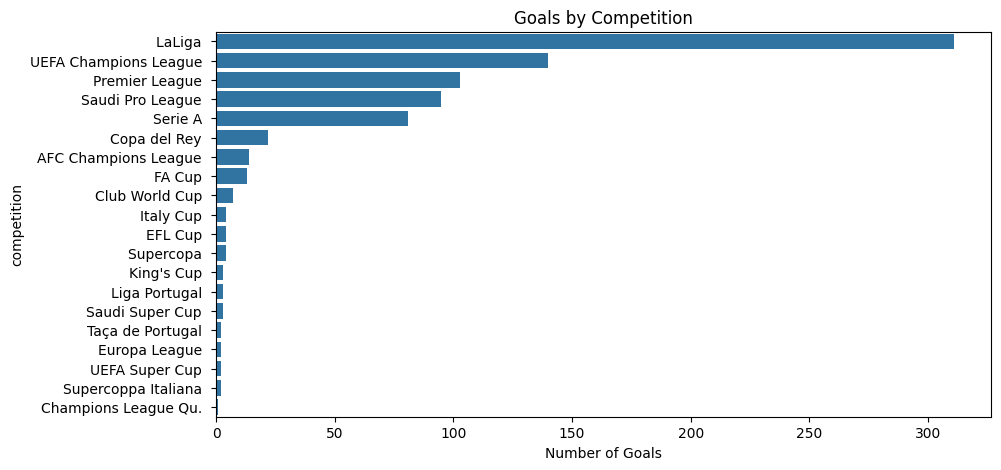

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(y='competition', data=df,
              order=df['competition'].value_counts().index)

plt.title("Goals by Competition")
plt.xlabel("Number of Goals")

plt.show()

## Goals by Stage

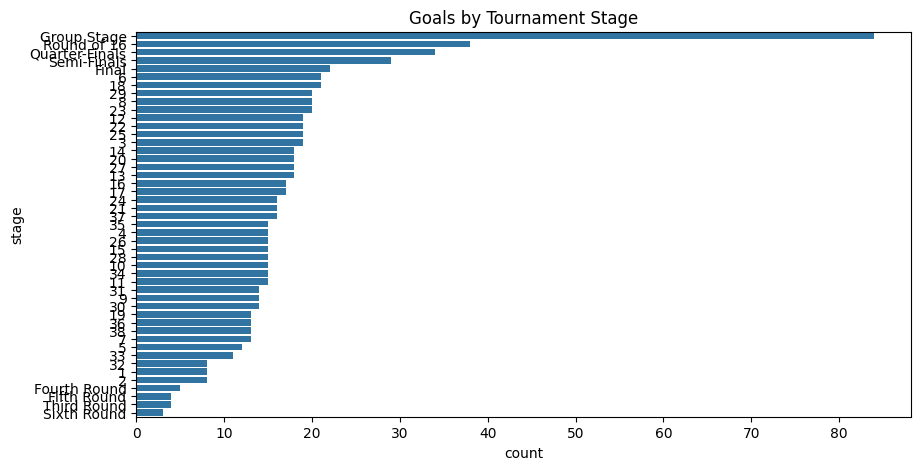

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(y='stage', data=df,
              order=df['stage'].value_counts().index)

plt.title("Goals by Tournament Stage")

plt.show()

## Home vs Away Goals

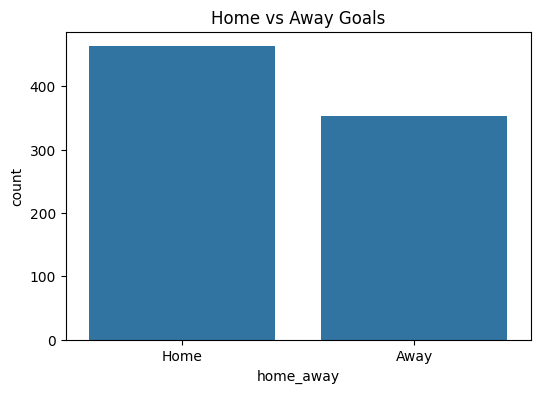

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='home_away', data=df)

plt.title("Home vs Away Goals")

plt.show()

## Goals by Opponent

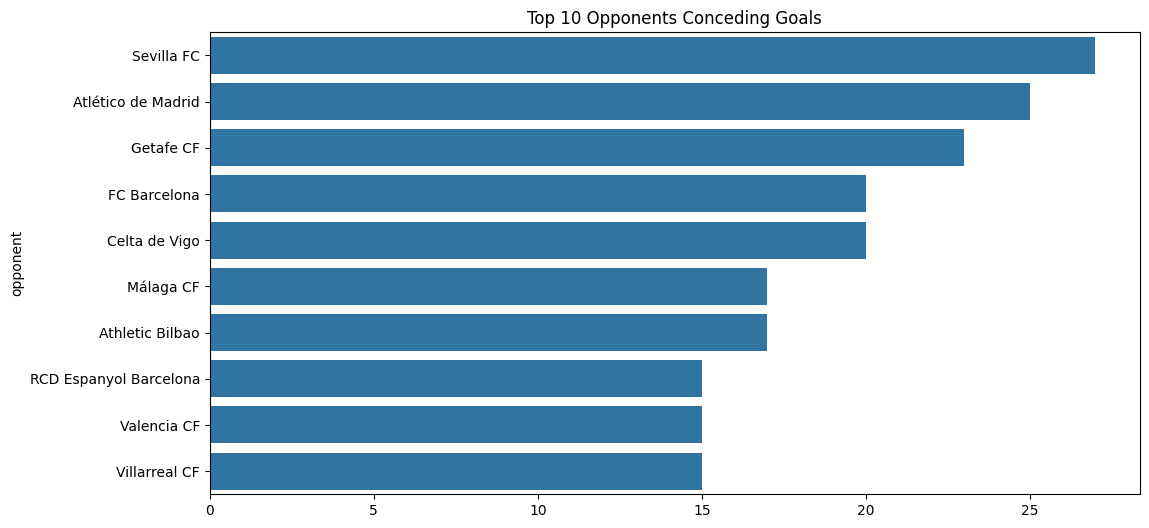

In [13]:
plt.figure(figsize=(12,6))

top_opponents = df['opponent'].value_counts().head(10)

sns.barplot(x=top_opponents.values,
            y=top_opponents.index)

plt.title("Top 10 Opponents Conceding Goals")

plt.show()

## Goals by Player Position 

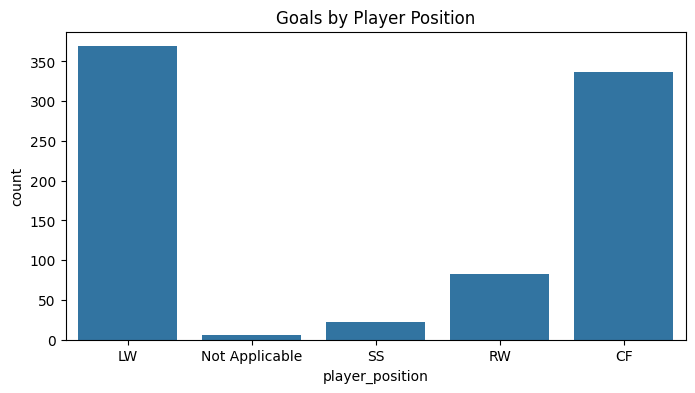

In [14]:
plt.figure(figsize=(8,4))

sns.countplot(x='player_position', data=df)

plt.title("Goals by Player Position")

plt.show()

## Goal Minute Distribution

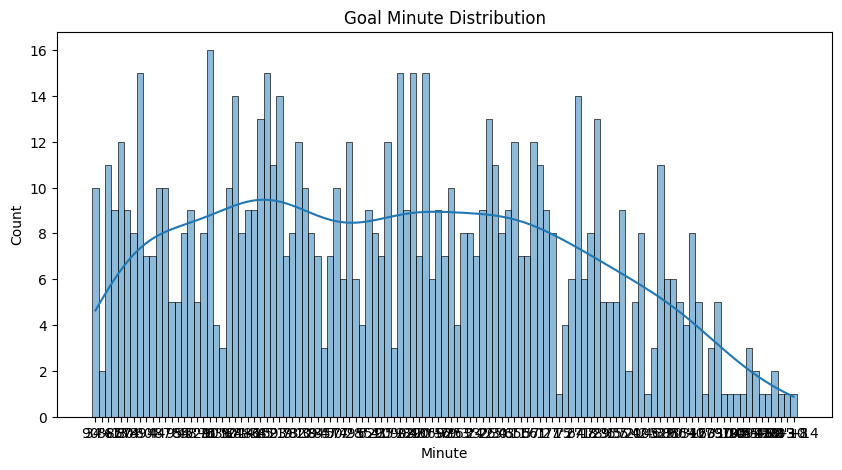

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(df['goal_minute'], bins=30, kde=True)

plt.title("Goal Minute Distribution")

plt.xlabel("Minute")

plt.show()

## Goals by Minute Bucket

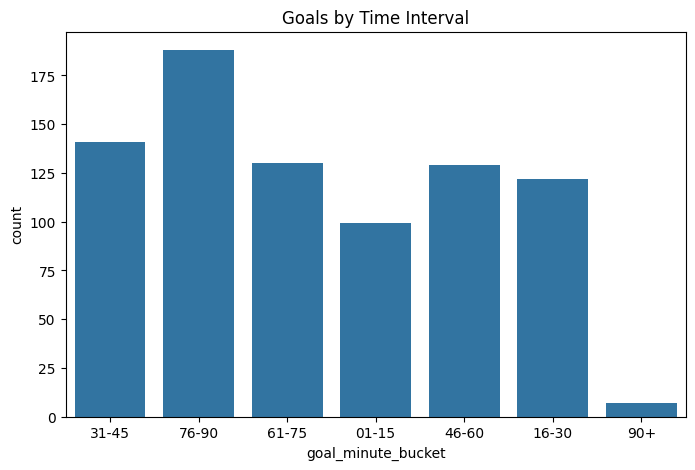

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(x='goal_minute_bucket', data=df)

plt.title("Goals by Time Interval")

plt.show()

## Goal Method Analysis

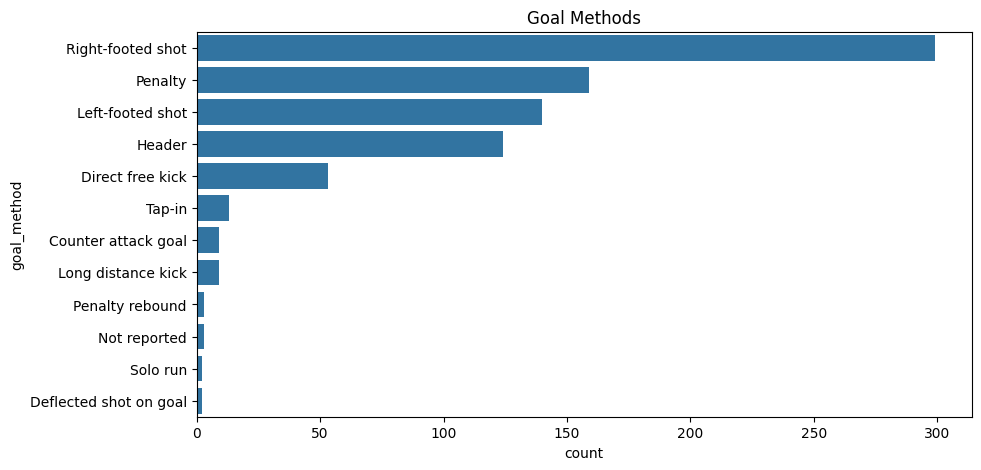

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(y='goal_method', data=df,
              order=df['goal_method'].value_counts().index)

plt.title("Goal Methods")

plt.show()

## Assists Analysis

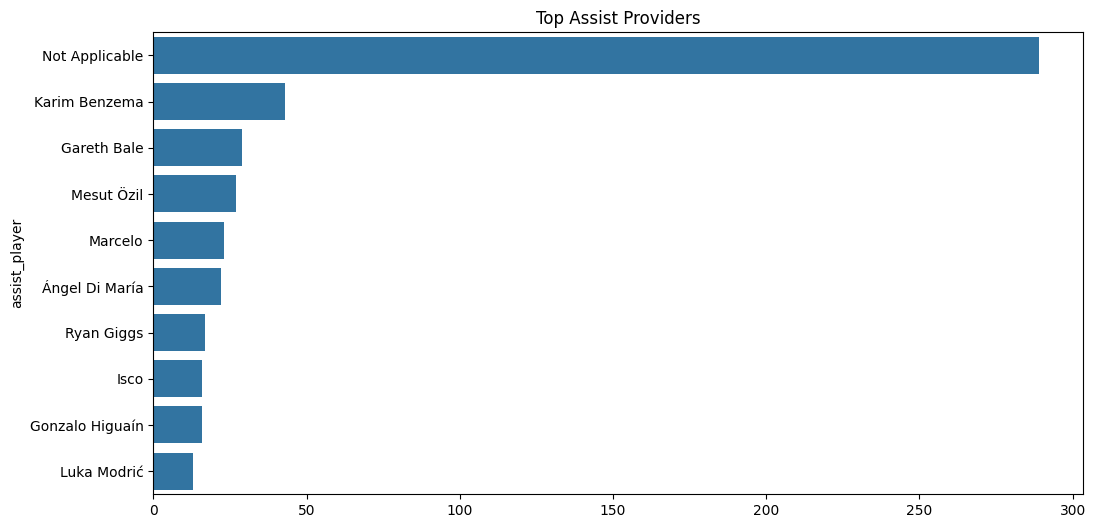

In [18]:
plt.figure(figsize=(12,6))

top_assists = df['assist_player'].value_counts().head(10)

sns.barplot(x=top_assists.values,
            y=top_assists.index)

plt.title("Top Assist Providers")

plt.show()

## Goals by Season

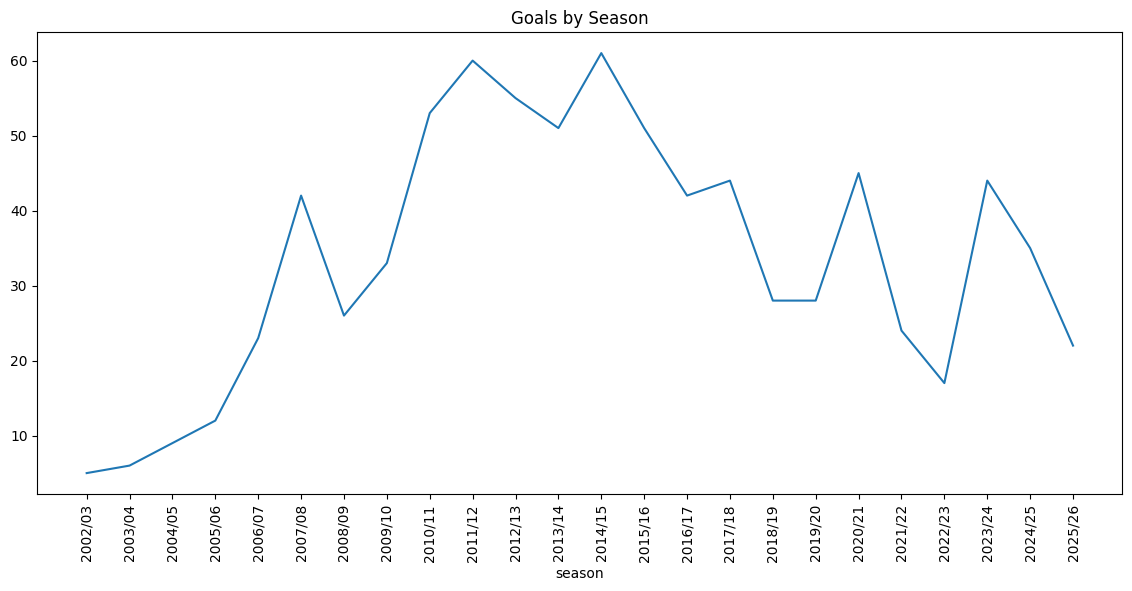

In [19]:
plt.figure(figsize=(14,6))

season_goals = df['season'].value_counts().sort_index()

sns.lineplot(x=season_goals.index,
             y=season_goals.values)

plt.xticks(rotation=90)

plt.title("Goals by Season")

plt.show()

## Goals by Decade

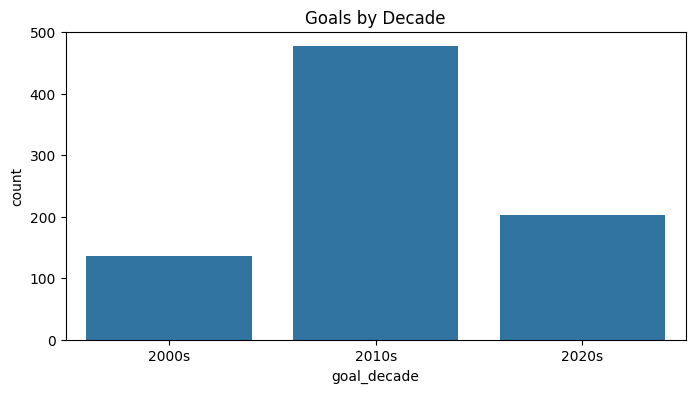

In [20]:
plt.figure(figsize=(8,4))

sns.countplot(x='goal_decade', data=df)

plt.title("Goals by Decade")

plt.show()

## Home Goals vs Away Goals

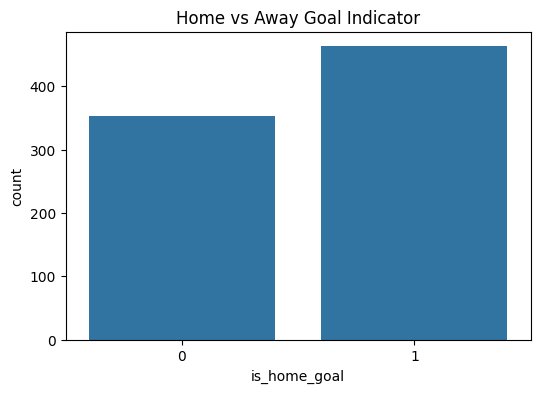

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_home_goal', data=df)

plt.title("Home vs Away Goal Indicator")

plt.show()

## Goal Method vs Competition

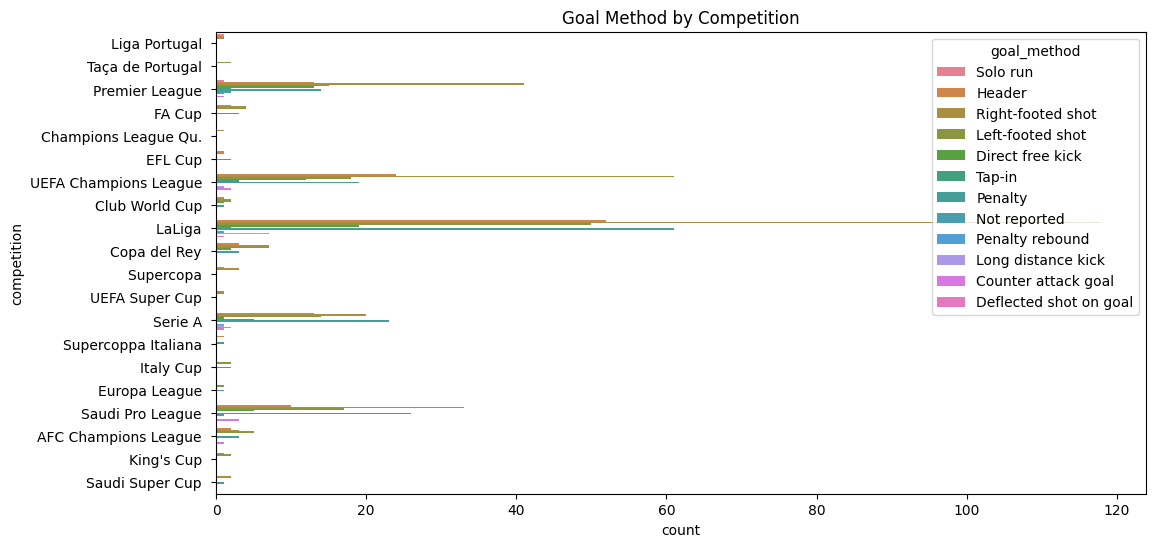

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(y='competition',
              hue='goal_method',
              data=df)

plt.title("Goal Method by Competition")

plt.show()

## Heatmap (Goals by Season and Competition)

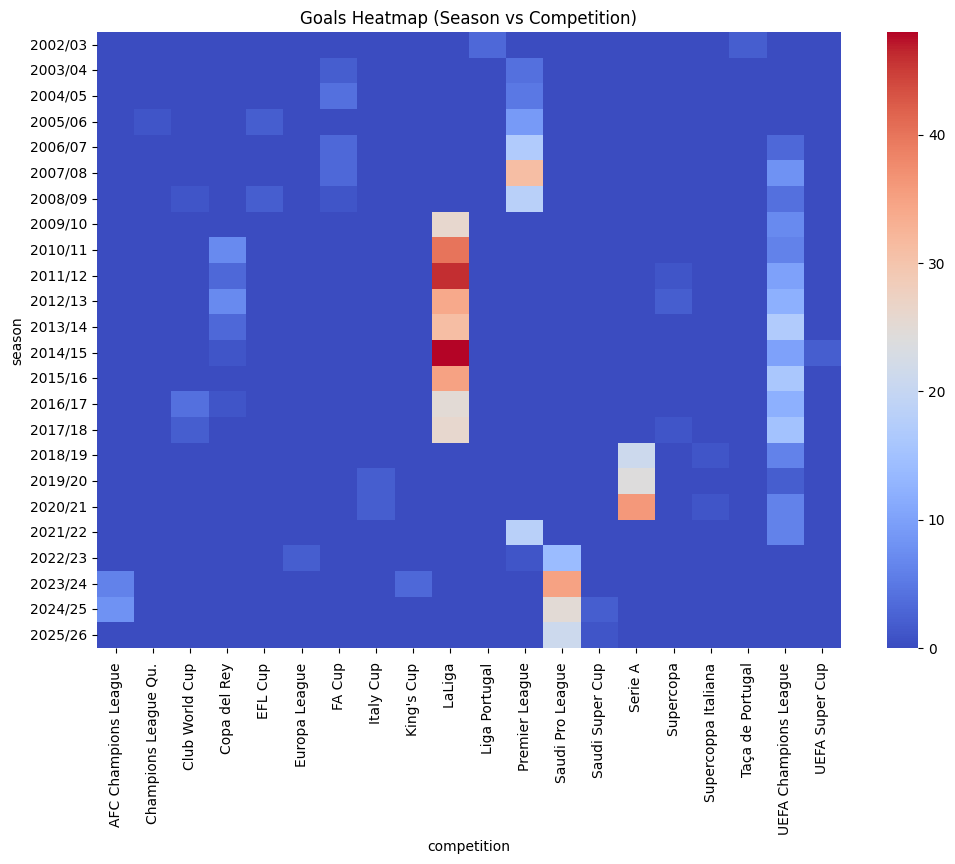

In [23]:
pivot = pd.pivot_table(
    df,
    index='season',
    columns='competition',
    aggfunc='size',
    fill_value=0
)

plt.figure(figsize=(12,8))

sns.heatmap(pivot, cmap='coolwarm')

plt.title("Goals Heatmap (Season vs Competition)")

plt.show()

## Pair Analysis

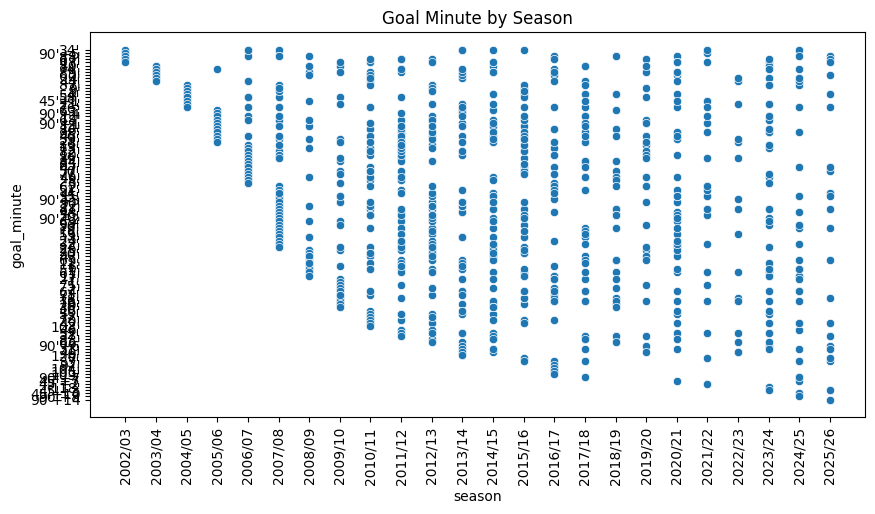

In [24]:
plt.figure(figsize=(10,5))

sns.scatterplot(x='season',
                y='goal_minute',
                data=df)

plt.xticks(rotation=90)

plt.title("Goal Minute by Season")

plt.show()

## Top Matches (Multiple Goals)

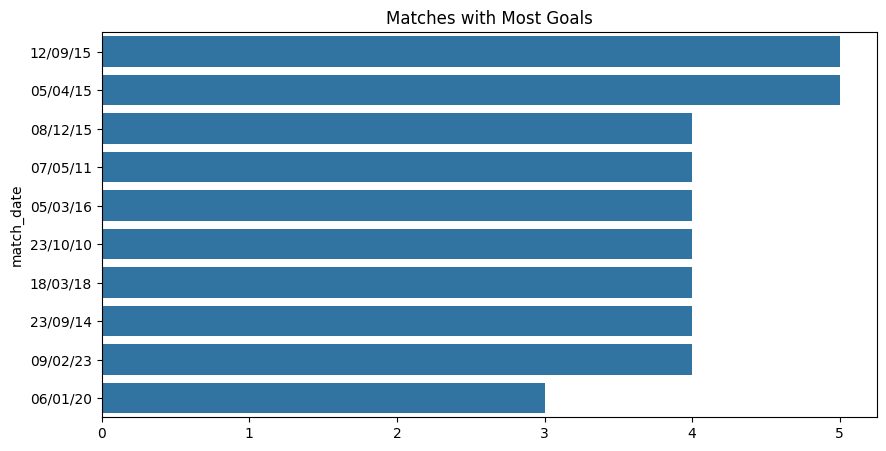

In [25]:
top_matches = df['match_date'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_matches.values,
            y=top_matches.index)

plt.title("Matches with Most Goals")

plt.show()

## Competition vs Home/Away Goals

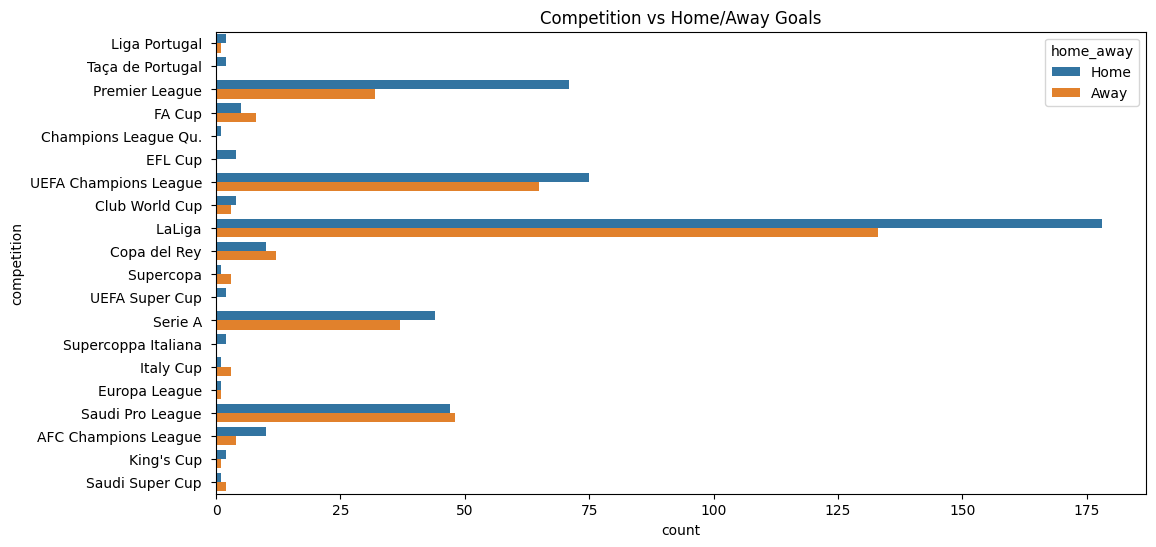

In [26]:
plt.figure(figsize=(12,6))

sns.countplot(y='competition',
              hue='home_away',
              data=df)

plt.title("Competition vs Home/Away Goals")

plt.show()

## Goal Minute Boxplot

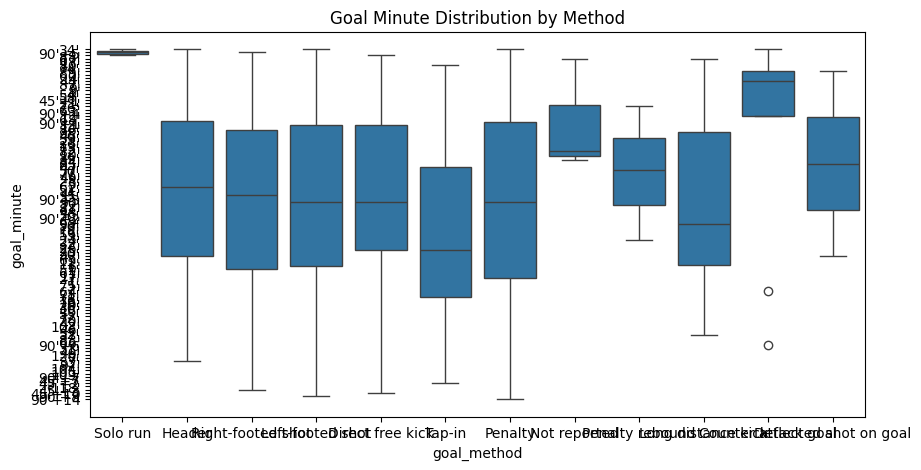

In [27]:
plt.figure(figsize=(10,5))

sns.boxplot(x='goal_method',
            y='goal_minute',
            data=df)

plt.title("Goal Minute Distribution by Method")

plt.show()

## Correlation Heatmap

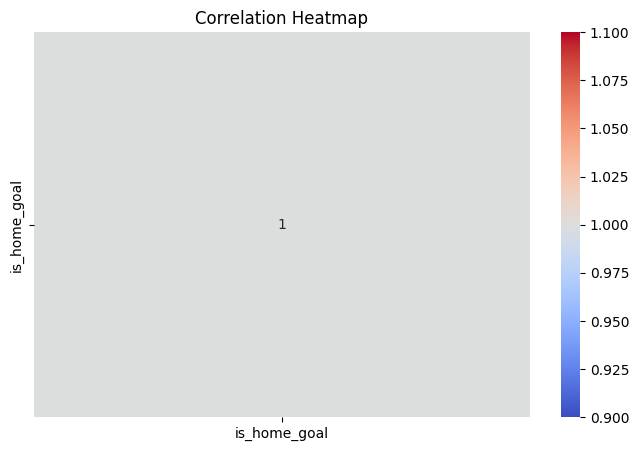

In [28]:
plt.figure(figsize=(8,5))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## Feature engineering

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc

In [30]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (816, 16)

Columns:
Index(['competition', 'stage', 'match_date', 'home_away', 'team', 'opponent',
       'final_score', 'player_position', 'goal_minute', 'score_after_goal',
       'goal_method', 'assist_player', 'season', 'goal_decade', 'is_home_goal',
       'goal_minute_bucket'],
      dtype='object')

Missing Values:
competition           0
stage                 0
match_date            0
home_away             0
team                  0
opponent              0
final_score           0
player_position       0
goal_minute           0
score_after_goal      0
goal_method           0
assist_player         0
season                0
goal_decade           0
is_home_goal          0
goal_minute_bucket    0
dtype: int64


In [31]:
df['match_date'] = pd.to_datetime(df['match_date'])

In [32]:
df['year'] = df['match_date'].dt.year
df['month'] = df['match_date'].dt.month
df['day'] = df['match_date'].dt.day

In [33]:
df['goal_minute'] = df['goal_minute'].astype(str)

df['goal_minute'] = df['goal_minute'].str.replace("'", "", regex=False)

df['goal_minute'] = df['goal_minute'].str.replace(r"\+.*", "", regex=True)

df['goal_minute'] = pd.to_numeric(df['goal_minute'], errors='coerce')

In [34]:
df = df.drop(columns=[
    'match_date',
    'final_score',
    'score_after_goal'
])

In [35]:
target = "goal_method"

X = df.drop(columns=[target])
y = df[target]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

In [39]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(n_estimators=200, random_state=42)

}

In [40]:
results = {}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    print("\n===============================")
    print("Model:", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Model: Logistic Regression
Accuracy: 0.5182926829268293
                     precision    recall  f1-score   support

Counter attack goal       0.00      0.00      0.00         2
   Direct free kick       0.50      0.18      0.27        11
             Header       0.43      0.12      0.19        25
   Left-footed shot       0.29      0.14      0.19        28
 Long distance kick       0.00      0.00      0.00         2
            Penalty       0.60      0.97      0.74        32
    Penalty rebound       0.00      0.00      0.00         1
  Right-footed shot       0.52      0.75      0.61        60
             Tap-in       0.00      0.00      0.00         3

           accuracy                           0.52       164
          macro avg       0.26      0.24      0.22       164
       weighted avg       0.45      0.52      0.45       164


Model: Decision Tree
Accuracy: 0.4268292682926829
                     precision    recall  f1-score   support

Counter attack goal       0.25    

In [41]:
results_df = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.518293
2        Random Forest  0.518293
1        Decision Tree  0.426829


In [42]:
y_test_bin = label_binarize(y_test, classes=y.unique())

n_classes = y_test_bin.shape[1]

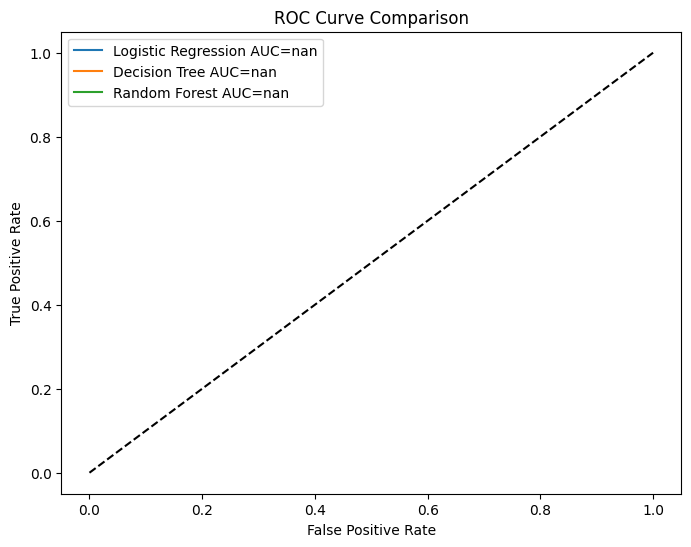

In [43]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(y_test_bin[:,0], y_prob[:,0])

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

## Thank you...pls upvote!!!!!!